# Exemplo 1C — horizonte de três anos

Reprodução auditada da aba `Example1C` do XLS. Cada par (contraparte, ano) com exposição positiva é uma exposição virtual, usando o perfil contratual e a taxa marginal condicional daquele ano. Isso produz 40 linhas virtuais a partir das 25 contrapartes.

In [1]:
# Carrega exatamente o perfil de exposição e as taxas do exemplo oficial.
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from creditriskplus import data
from creditriskplus.simple_model import calculate_loss_distribution_detailed

portfolio = data.create_example_1c_portfolio()
assert len(portfolio) == 40
display(portfolio.head())
display(portfolio.groupby('year').agg(virtual_exposures=('virtual_id','count'),
                                      exposure=('exposure','sum')))

,virtual_id,obligor_id,year,exposure,rating,mean_default_rate,std_default_rate,sector_weight_general_economy
0,1,1,1,358475.0,H,0.30,0.150,1.0
1,2,2,1,1089819.0,H,0.30,0.150,1.0
2,3,3,1,1799710.0,F,0.10,0.050,1.0
3,4,4,1,1933116.0,G,0.15,0.075,1.0
4,5,5,1,2317327.0,G,0.15,0.075,1.0


,virtual_exposures,exposure
year,,
1,25,130513072.0
2,10,34272344.5
3,5,20672293.0


## Hipótese temporal

A PGF recebe todas as exposições virtuais no mesmo fator de economia geral. Portanto, o resultado incorpora dependência por esse fator, mas não uma matriz de transição de rating nem correlação serial estimada separadamente. O método é a reprodução do exemplo fornecido, não um motor genérico de lifetime credit loss.

In [2]:
# Calcula a distribuição acumulada de três anos sem renormalizar a cauda.
result = calculate_loss_distribution_detailed(
    portfolio.exposure, portfolio.mean_default_rate, portfolio.std_default_rate,
    np.zeros(len(portfolio)), max_loss_dollars=200_000_000,
)
reference_el, reference_var99 = 17_277_632.0, 62_100_307.0
comparison = pd.DataFrame({
    'Métrica': ['EL', 'VaR99 interpolado (XLS)', 'VaR99 discreto', 'Massa truncada'],
    'Python': [result.expected_loss, result.quantile(.99, interpolate=True),
               result.quantile(.99), result.tail_mass_upper_bound],
    'Referência': [reference_el, reference_var99, np.nan, 0.0],
})
display(comparison.round(4))
assert abs(result.expected_loss-reference_el) < 1
assert abs(result.quantile(.99, interpolate=True)-reference_var99) < 1
assert result.tail_mass_upper_bound < 1e-8

,Métrica,Python,Referência
0,EL,1.727763e+07,17277632.0
1,VaR99 interpolado (XLS),6.210031e+07,62100307.0
2,VaR99 discreto,6.213342e+07,NaN
3,Massa truncada,0.000000e+00,0.0


,year,exposure,expected_loss
0,1,130513072.0,1.422186e+07
1,2,34272344.5,1.944332e+06
2,3,20672293.0,1.111436e+06


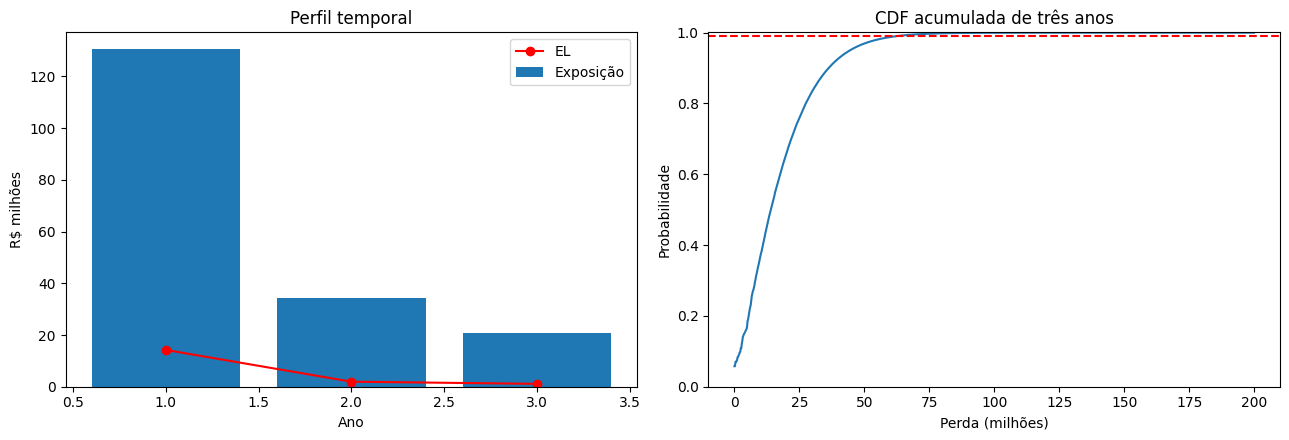

In [3]:
# Decomposição da EL e perfil de exposição por ano.
yearly = portfolio.assign(expected_loss=portfolio.exposure*portfolio.mean_default_rate)
yearly = yearly.groupby('year', as_index=False).agg(exposure=('exposure','sum'),
                                                     expected_loss=('expected_loss','sum'))
display(yearly)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(yearly.year, yearly.exposure/1e6, label='Exposição')
axes[0].plot(yearly.year, yearly.expected_loss/1e6, marker='o', color='red', label='EL')
axes[0].set(title='Perfil temporal', xlabel='Ano', ylabel='R$ milhões'); axes[0].legend()
losses = np.arange(len(result.pmf))*result.unit_size
axes[1].plot(losses/1e6, result.cdf)
axes[1].axhline(.99, color='red', ls='--')
axes[1].set(title='CDF acumulada de três anos', xlabel='Perda (milhões)', ylabel='Probabilidade', ylim=(0,1.001))
plt.tight_layout(); plt.show()

EL e VaR interpolado reproduzem a aba oficial com diferença inferior a uma unidade monetária. Para uso real, exposições futuras, amortização, pré-pagamento, migração e dependência temporal devem ser estimados e validados; não se deve simplesmente multiplicar a PD do primeiro ano.